# 📝 **Tarea semana 4 - Opción Low-Code: Imputación de valores faltantes y modelado de series temporales**

## 📌 **Descripción del dataset**

El conjunto de datos corresponde a mediciones de calidad del aire recogidas en una estación en Italia, con registros horarios entre marzo de 2004 y abril de 2005.
Las variables principales son:

| N° | Variable      | Descripción                                                               |
| -- | ------------- | ------------------------------------------------------------------------- |
| 2  | CO(GT)        | Concentración verdadera de CO (mg/m³, referencia)                         |
| 3  | PT08.S1(CO)   | Respuesta del sensor de óxido de estaño (target: CO)                      |
| 4  | NMHC(GT)      | Concentración verdadera de hidrocarburos no metánicos (μg/m³, referencia) |
| 5  | C6H6(GT)      | Concentración verdadera de benceno (μg/m³, referencia)                    |
| 6  | PT08.S2(NMHC) | Respuesta del sensor de titania (target: NMHC)                            |
| 7  | NOx(GT)       | Concentración verdadera de NOx (ppb, referencia)                          |
| 8  | PT08.S3(NOx)  | Respuesta del sensor de óxido de tungsteno (target: NOx)                  |
| 9  | NO2(GT)       | Concentración verdadera de NO2 (μg/m³, referencia)                        |
| 10 | PT08.S4(NO2)  | Respuesta del sensor de óxido de tungsteno (target: NO2)                  |
| 11 | PT08.S5(O3)   | Respuesta del sensor de óxido de indio (target: O3)                       |
| 12 | T             | Temperatura (°C)                                                          |
| 13 | RH            | Humedad relativa (%)                                                      |
| 14 | AH            | Humedad absoluta                                                          |


## 🎯 **Propósito de la tarea**

La tarea tiene dos objetivos principales:

### 1️⃣ **Imputación de valores faltantes**


* Simular valores faltantes en el dataset mediante dos enfoques:

  * **Aleatorio (at random)**: Se eliminan valores de forma dispersa.
  * **En bloques (in blocks)**: Se eliminan valores en secuencias consecutivas para simular fallos de sensores.
* Aplicar un método de imputación (por ejemplo, interpolación, modelo simple, técnica automática de la biblioteca proporcionada) para completar los datos.

### 2️⃣ **Modelado de serie temporal**


* Seleccionar una variable adecuada para modelar con un **LSTM** o un **Transformer**.
* La variable recomendada es:
  **CO(GT)** (Concentración de monóxido de carbono en mg/m³)
  👉 **Justificación:** CO(GT) es una variable con patrones estacionales y tendencias temporales claras, es de interés ambiental y presenta correlación con otras mediciones del dataset.
* Desarrollar un modelo básico (low-code) para predecir el valor futuro de CO(GT), usando las variables disponibles como entradas y evaluando el desempeño del modelo.


## ⚙️ **Instrucciones**

* Esta es una tarea **low-code**: Se proporcionarán plantillas de código o scripts básicos, enfócate en:

  * Comprender el proceso de imputación y modelado.
  * Ejecutar el flujo de trabajo.
  * Interpretar y discutir los resultados: calidad de la imputación y precisión del modelo de predicción.
* Analizar las métricas (MAE, MSE, RMSE, R²) para la imputación y la predicción.


## ✅ **Entregables**

* Un breve informe que incluya:

  * Gráficos de la serie original, con y sin imputación.
  * Métricas de evaluación de la imputación.
  * Gráficos y métricas del modelo LSTM o Transformer (por ejemplo: RMSE en test).
  * Reflexión sobre la calidad de la imputación y el modelo.

## 🎯 Generación de valores faltantes aleatorios (Missing At Blocks)

En esta parte se introduce un 20% de valores faltantes en el dataset diario en forma de bloques en cada columna. Esto simula errores aislados en la medición, típicos de fallos esporádicos en los sensores.


In [10]:
!pip install missingno

# ----------------------------------------
# 📌 IMPORTAR LIBRERÍAS
# ----------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [11]:
# ----------------------------------------
# 📌 CARGAR EL DATASET
# ----------------------------------------
df = pd.read_csv('https://raw.githubusercontent.com/marsgr6/rna-online/refs/heads/main/data/AirQualityUCI.csv')
df.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
5,3/10/2004,23:00:00,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
6,3/11/2004,0:00:00,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
7,3/11/2004,1:00:00,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
8,3/11/2004,2:00:00,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648
9,3/11/2004,3:00:00,0.6,1010,19,1.7,561,-200,1705,-200,1235,501,10.3,60.2,0.7517


In [12]:
# Combina fecha y hora en un solo índice de tipo datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.drop(columns=['Date', 'Time'])
df = df.set_index('DateTime')
df.head(10)

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
2004-03-10 23:00:00,1.2,1197,38,4.7,750,89,1337,96,1393,949,11.2,59.2,0.7848
2004-03-11 00:00:00,1.2,1185,31,3.6,690,62,1462,77,1333,733,11.3,56.8,0.7603
2004-03-11 01:00:00,1.0,1136,31,3.3,672,62,1453,76,1333,730,10.7,60.0,0.7702
2004-03-11 02:00:00,0.9,1094,24,2.3,609,45,1579,60,1276,620,10.7,59.7,0.7648


In [13]:
df.shape

(9357, 13)

In [14]:
# Convierte los datos a numérico y reemplaza valores negativos por 0
df = df.apply(pd.to_numeric, errors='coerce')
df[df < 0] = 0

# Elimina la columna NMHC(GT) por calidad de datos
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])

# Resamplea a datos diarios calculando la media
df_daily = df.resample('D').mean()
df_original = df_daily.copy()

In [15]:
df_daily

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,
2004-03-10,1.966667,1316.500000,8.450000,912.333333,132.000000,1167.333333,108.833333,1545.500000,1096.000000,12.033333,54.900000,0.765633
2004-03-11,2.145833,1244.166667,7.979167,851.958333,138.375000,1277.250000,95.708333,1522.833333,885.250000,9.837500,64.075000,0.775767
2004-03-12,2.570833,1281.666667,12.129167,1008.291667,159.250000,1101.875000,106.583333,1627.291667,1084.375000,11.287500,51.095833,0.663104
2004-03-13,2.583333,1330.666667,10.916667,992.833333,176.750000,993.208333,113.916667,1595.791667,1245.916667,12.866667,51.533333,0.732296
2004-03-14,2.366667,1361.125000,9.637500,943.916667,140.500000,1001.291667,105.791667,1602.375000,1234.208333,16.012500,48.850000,0.849671
...,...,...,...,...,...,...,...,...,...,...,...,...
2005-03-31,1.387500,1008.125000,5.220833,749.416667,185.083333,795.666667,100.708333,1176.541667,763.833333,17.550000,50.083333,0.951917
2005-04-01,1.062500,903.291667,3.412500,663.000000,161.833333,946.875000,107.333333,943.250000,523.958333,15.929167,35.962500,0.636529
2005-04-02,0.854167,890.958333,2.529167,616.291667,142.375000,991.750000,100.166667,864.333333,481.750000,15.483333,32.225000,0.546167


In [16]:
df_daily.shape

(391, 12)

Number of missing values introduced: 838


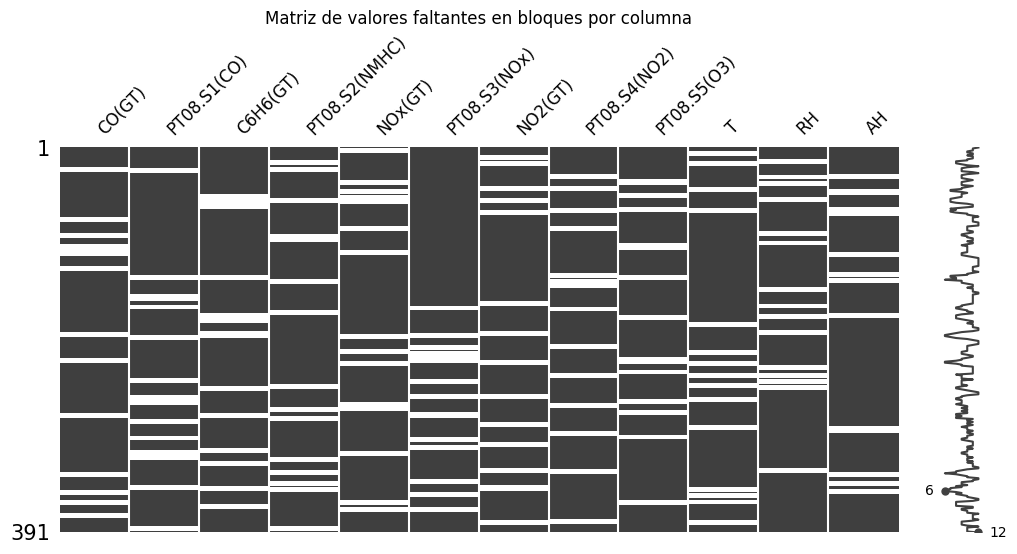

In [28]:
# ----------------------------------------
# 📌 INTRODUCIR VALORES FALTANTES ALEATORIAMENTE POR COLUMNA
# ----------------------------------------
def introduce_missing_per_column(data, frac=0.2):
    """
    Introduce valores faltantes de forma aleatoria por columna.
    
    Parámetros:
    - data: DataFrame de entrada
    - frac: Fracción de datos a eliminar por columna
    
    Retorna:
    - data_missing: DataFrame con valores faltantes introducidos
    - nan_mask: Máscara booleana que marca los NaN introducidos
    """
    data_missing = data.copy()
    nan_mask = pd.DataFrame(False, index=data.index, columns=data.columns)  # Máscara para rastrear NaNs
    #np.random.seed(42)  # Fijar semilla para reproducibilidad

    for column in data.columns:
        n_total = len(data[column])
        n_missing = int(n_total * frac)  # Cantidad de valores a eliminar
        missing_positions = np.random.choice(n_total, n_missing, replace=False, random_state=42)  # Índices aleatorios
        # Introducir NaN
        data_missing.iloc[missing_positions, data.columns.get_loc(column)] = np.nan
        nan_mask.iloc[missing_positions, data.columns.get_loc(column)] = True

    print(f"Number of missing values introduced: {nan_mask.sum().sum()}")
    return data_missing, nan_mask

def introduce_missing_blocks(data, frac=0.2, block_size=5):
    """
    Introduce missing data in contiguous blocks.

    Parameters:
    - data: DataFrame
    - frac: Fraction of data points to set as NaN
    - block_size: Number of consecutive rows in each missing block

    Returns:
    - data_missing: DataFrame with missing values
    - nan_mask: Boolean DataFrame where True = missing position introduced
    """
    data_missing = data.copy()
    nan_mask = pd.DataFrame(False, index=data.index, columns=data.columns)

    n_total = len(data)
    n_blocks_per_col = int((n_total * frac) / block_size)

    np.random.seed(42)

    for col in data.columns:
        for _ in range(n_blocks_per_col):
            start_idx = np.random.randint(0, n_total - block_size + 1)
            block_idx = data.index[start_idx : start_idx + block_size]

            data_missing.loc[block_idx, col] = np.nan
            nan_mask.loc[block_idx, col] = True

    print(f"Number of missing values introduced: {nan_mask.sum().sum()}")
    return data_missing, nan_mask

df_missing, nan_mask = introduce_missing_blocks(df_daily, frac=0.2, block_size=5)

# Visualize
import missingno as msno
msno.matrix(df_missing, figsize=(12, 5), fontsize=12)
plt.title("Matriz de valores faltantes en bloques por columna")
plt.show()

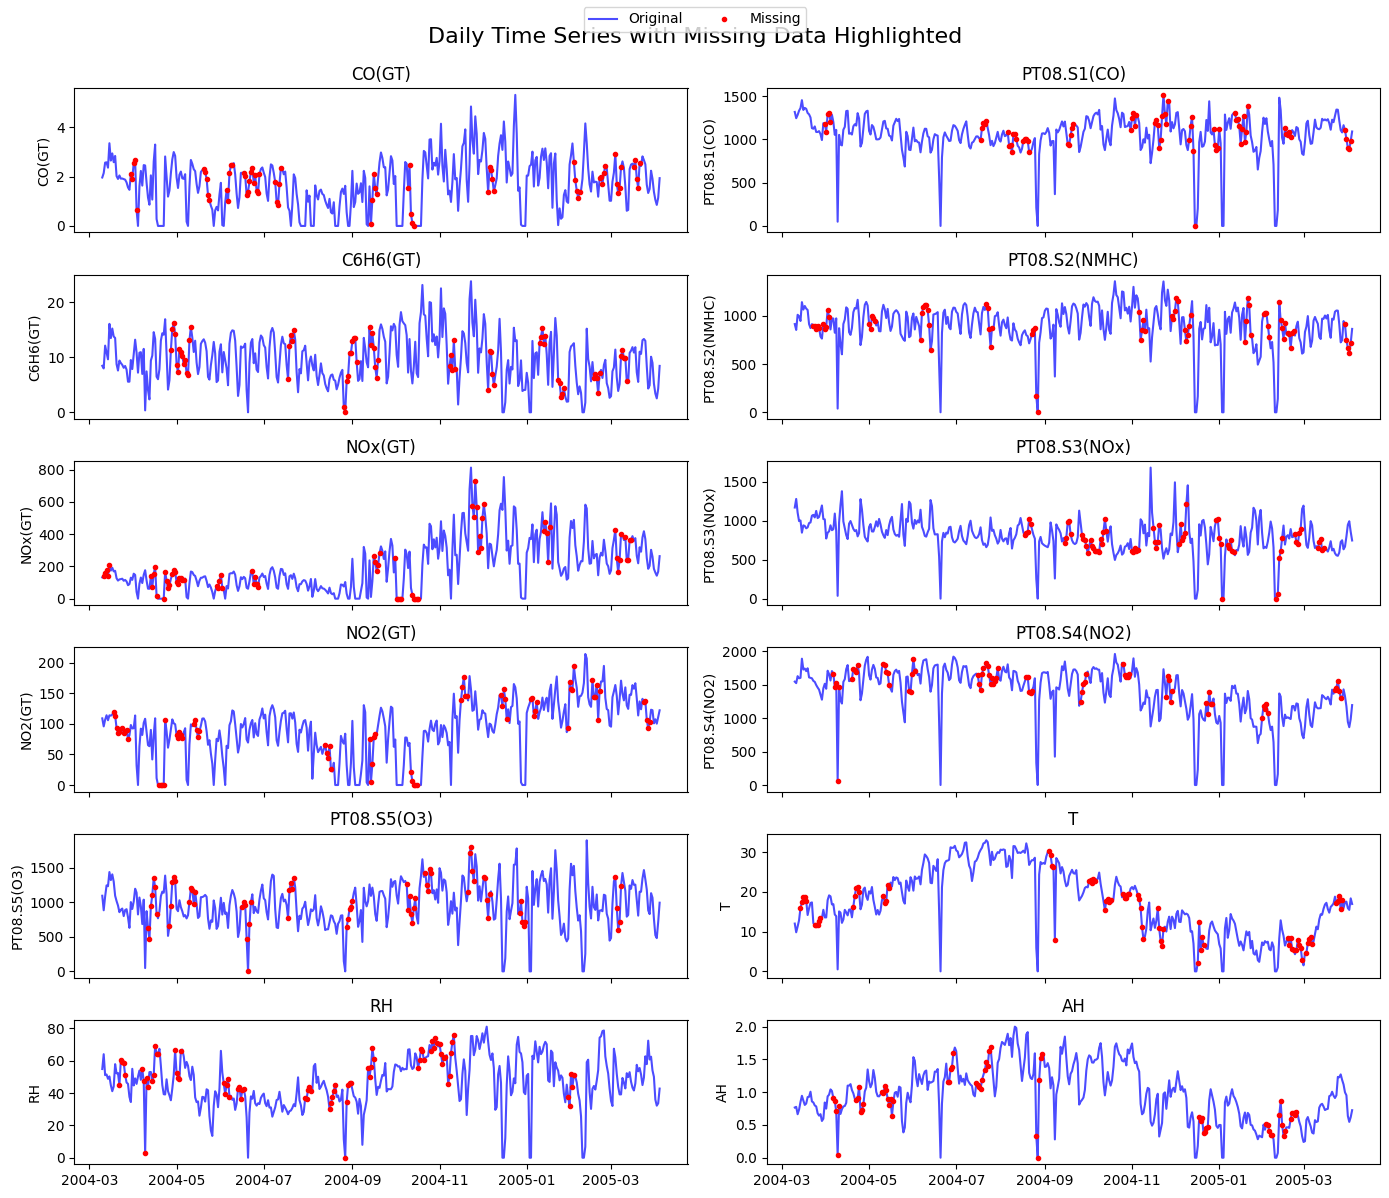

In [29]:
# ----------------------------------------
# 📌 PLOT SERIES TEMPORALES EN 2 COLUMNAS (CON PUNTOS ROJOS PARA MISSING)
# ----------------------------------------
cols = df_missing.columns
n_cols = 2
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2 * n_rows), sharex=True)

axes = axes.reshape(n_rows, n_cols)

for i, col in enumerate(cols):
    ax = axes[i // n_cols, i % n_cols]

    # Whole series as a blue line
    ax.plot(df_missing.index, df_original[col], color='blue', alpha=0.7, label='Original')

    # Red dots where missing
    ax.plot(df_missing.index[df_missing[col].isna()],
            df_original[col][df_missing[col].isna()],
            'r.', label='Missing', markersize=6)

    ax.set_title(f"{col}")
    ax.set_ylabel(col)

# Remove empty subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Daily Time Series with Missing Data Highlighted", fontsize=16)
plt.show()



### ✅ Lo que se espera

- Ejecutar el código y analizar los gráficos generados.

- Reflexionar: ¿Cómo se distribuyen los valores faltantes aleatorios? ¿Qué impacto tendría esto en la imputación?

## 🎯 Imputación de valores faltantes con SAITS

- Requistos:

In [19]:
!pip install pypots==0.11

En esta sección se utiliza el modelo **SAITS** (Self-Attention-based Imputation for Time Series) del paquete `pypots` para imputar los valores faltantes generados previamente.  
El modelo está basado en transformers y es capaz de capturar dependencias temporales en las series.

In [30]:
import missingno as msno
import pandas as pd
import numpy as np
from pypots.imputation import SAITS
from sklearn.preprocessing import MinMaxScaler

# ----------------------------------------
# 📌 CONFIGURACIÓN DE PARÁMETROS
# ----------------------------------------
seq_len = 7  # Longitud de la ventana temporal (por ejemplo, 7 días)
n_features = len(df_missing.columns)  # Número de variables (columnas)

# ----------------------------------------
# 📌 PREPARAR LOS DATOS PARA SAITS
# ----------------------------------------
# Convertir DataFrame a array numpy
data = df_missing.to_numpy(dtype=np.float32)

# Generar ventanas deslizantes de longitud seq_len
n_samples = len(data) - seq_len + 1
X = np.array([data[i:i + seq_len] for i in range(n_samples)])
print("Shape de X:", X.shape)

Shape de X: (385, 7, 12)


In [31]:
# ----------------------------------------
# 📌 AJUSTAR X PARA QUE COINCIDA CON EL NÚMERO DE DÍAS ORIGINALES
# ----------------------------------------
# Repetir y rellenar filas para cubrir todos los días
repeat_factor = data.shape[0] // X.shape[0]
extra_rows = data.shape[0] % X.shape[0]

expanded_arr = np.repeat(X, repeat_factor, axis=0)
expanded_arr = np.vstack([expanded_arr, X[:extra_rows]])

# Asegurar que las últimas filas coincidan con los datos originales
expanded_arr[-extra_rows:, 0, :] = data[-extra_rows:]
print("Shape de X expandido:", expanded_arr.shape)

# ----------------------------------------
# 📌 NORMALIZAR LOS DATOS
# ----------------------------------------
scaler = MinMaxScaler()
X_reshaped = expanded_arr.reshape(-1, expanded_arr.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled.reshape(expanded_arr.shape)
print("Shape de X escalado:", X_scaled.shape)

# ----------------------------------------
# 📌 ENTRENAR EL MODELO SAITS
# ----------------------------------------
saits = SAITS(n_steps=seq_len, n_features=n_features,
              n_layers=2, d_model=256, d_ffn=128,
              n_heads=4, d_k=64, d_v=64, dropout=0.1, epochs=100)

dataset = {"X": X_scaled}
saits.fit(dataset)  # Entrenar el modelo
imputation = saits.impute(dataset)  # Imputar los valores faltantes

# ----------------------------------------
# 📌 DESNORMALIZAR LA IMPUTACIÓN
# ----------------------------------------
imputation_reshaped = imputation.reshape(-1, imputation.shape[-1])
imputation_denorm = scaler.inverse_transform(imputation_reshaped)
imputation_denorm = imputation_denorm.reshape(imputation.shape)

# Tomar las primeras posiciones imputadas de cada ventana
imputed_values = imputation_denorm[:, 0, :]
print("Shape de los datos imputados finales:", imputed_values.shape)

# Reconstruir el DataFrame con los valores imputados
data_imputed = pd.DataFrame(imputed_values, columns=df.columns, index=df_original.index[:imputed_values.shape[0]])

2025-09-04 20:12:43 [INFO]: No given device, using default device: cpu
2025-09-04 20:12:43 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.


Shape de X expandido: (391, 7, 12)
Shape de X escalado: (391, 7, 12)


2025-09-04 20:12:43 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,335,716
2025-09-04 20:12:45 [INFO]: Epoch 001 - training loss (MSE): 0.3507
2025-09-04 20:12:45 [INFO]: Epoch 002 - training loss (MSE): 0.1870
2025-09-04 20:12:46 [INFO]: Epoch 003 - training loss (MSE): 0.1563
2025-09-04 20:12:47 [INFO]: Epoch 004 - training loss (MSE): 0.1315
2025-09-04 20:12:47 [INFO]: Epoch 005 - training loss (MSE): 0.1162
2025-09-04 20:12:48 [INFO]: Epoch 006 - training loss (MSE): 0.0966
2025-09-04 20:12:50 [INFO]: Epoch 007 - training loss (MSE): 0.0845
2025-09-04 20:12:50 [INFO]: Epoch 008 - training loss (MSE): 0.0777
2025-09-04 20:12:51 [INFO]: Epoch 009 - training loss (MSE): 0.0638
2025-09-04 20:12:52 [INFO]: Epoch 010 - training loss (MSE): 0.0589
2025-09-04 20:12:53 [INFO]: Epoch 011 - training loss (MSE): 0.0547
2025-09-04 20:12:54 [INFO]: Epoch 012 - training loss (MSE): 0.0507
2025-09-04 20:12:55 [INFO]: Epoch 013 - training loss (MSE):

Shape de los datos imputados finales: (391, 12)


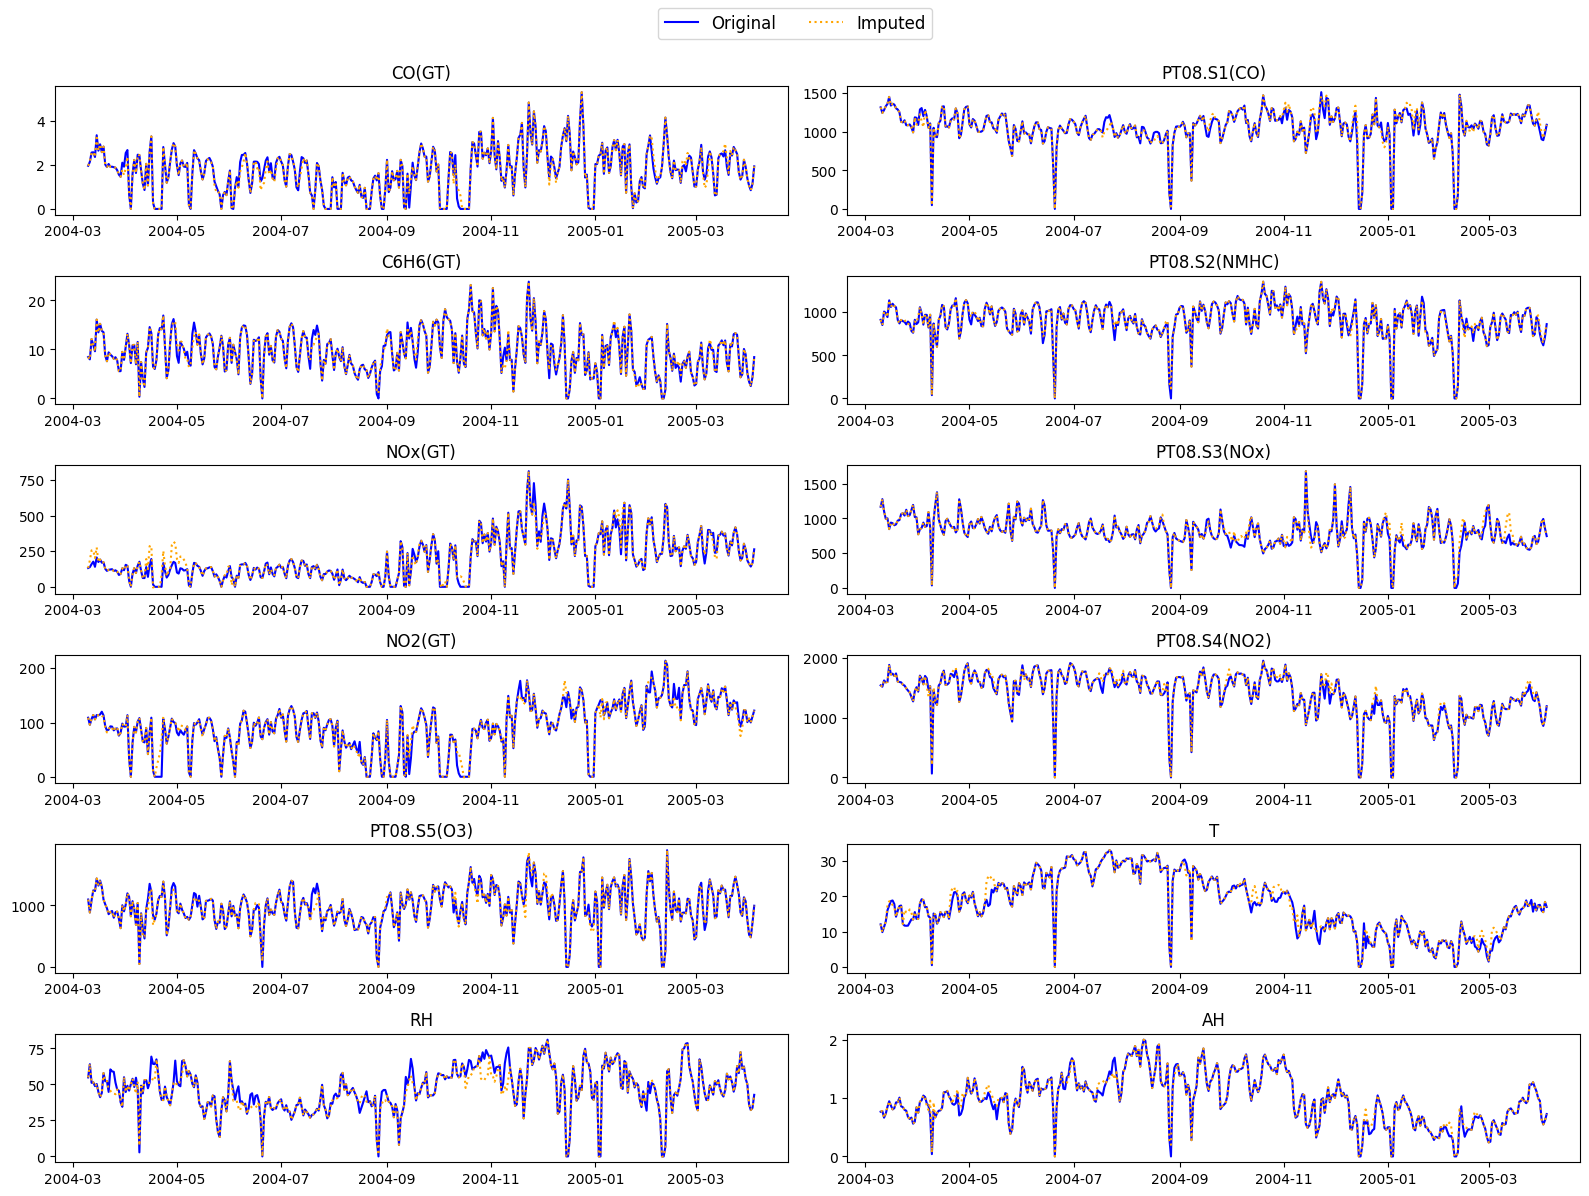

In [32]:
# ----------------------------------------
# 📌 VISUALIZAR ORIGINAL VS IMPUTADO
# ----------------------------------------
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    int(np.ceil(len(df_original.columns) / 2)), 2, figsize=(16, 2 * int(np.ceil(len(df_original.columns) / 2)))
)

for ax, col in zip(axes.flat, df_original.columns):
    ax.plot(df_original.index, df_original[col], label="Original", color='blue')
    ax.plot(df_original.index, data_imputed[col], ':', label="Imputed", color='orange')
    ax.set_title(col)

fig.legend(['Original', 'Imputed'], loc='upper center', ncol=2, fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [33]:
# Importamos las métricas para evaluar el modelo
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Calculamos las métricas de evaluación
mse = mean_squared_error(data_imputed['CO(GT)'], df_original['CO(GT)'])
r2 = r2_score(data_imputed['CO(GT)'], df_original['CO(GT)'])
mae = mean_absolute_error(data_imputed['CO(GT)'], df_original['CO(GT)'])

# Imprimimos las métricas de evaluación
print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Coeficiente de Determinación (R^2): {r2}')
print(f'Error Absoluto Medio (MAE): {mae}')

Error Cuadrático Medio (MSE): 0.019236053909825315
Coeficiente de Determinación (R^2): 0.9803698599402915
Error Absoluto Medio (MAE): 0.04789116967801336


In [34]:
# Calcula las métricas de evaluación para todas las columnas
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

metricas = []

for col in data_imputed.columns:
    mse = mean_squared_error(data_imputed[col], df_original[col])
    mae = mean_absolute_error(data_imputed[col], df_original[col])
    rmse = np.sqrt(mse)
    r2 = r2_score(data_imputed[col], df_original[col])
    metricas.append({
        'Variable': col,
        'MAE': round(mae, 3),
        'MSE': round(mse, 3),
        'RMSE': round(rmse, 3),
        'R2': round(r2, 3)
    })

df_metricas = pd.DataFrame(metricas)
print(df_metricas)

         Variable     MAE       MSE    RMSE     R2
0          CO(GT)   0.048     0.019   0.139  0.980
1     PT08.S1(CO)  14.173  1501.276  38.746  0.973
2        C6H6(GT)   0.171     0.287   0.536  0.985
3   PT08.S2(NMHC)   6.870   423.193  20.572  0.991
4         NOx(GT)   9.361   723.832  26.904  0.970
5    PT08.S3(NOx)  15.571  2373.132  48.715  0.949
6         NO2(GT)   2.342    61.284   7.828  0.969
7    PT08.S4(NO2)  13.980  1684.558  41.043  0.988
8     PT08.S5(O3)  15.609  2437.297  49.369  0.976
9               T   0.478     1.823   1.350  0.973
10             RH   1.479    17.753   4.213  0.916
11             AH   0.019     0.003   0.056  0.982



## 📊 Resultados de la imputación con SAITS

| Variable        | MAE    | MSE       | RMSE   | R²      |
|-----------------|--------|-----------|--------|---------|
| CO(GT)          | 0.281  | 0.106     | 0.326  | 0.746   |
| PT08.S1(CO)     | 61.061 | 5673.883  | 75.325 | 0.850   |
| C6H6(GT)        | 0.995  | 1.878     | 1.370  | 0.872   |
| PT08.S2(NMHC)   | 37.641 | 2561.053  | 50.607 | 0.929   |
| NOx(GT)         | 48.429 | 3705.005  | 60.869 | 0.866   |
| PT08.S3(NOx)    | 70.764 | 9218.081  | 96.011 | 0.780   |
| NO2(GT)         | 15.125 | 357.961   | 18.920 | 0.861   |
| PT08.S4(NO2)    | 78.496 | 10095.427 | 100.476| 0.858   |
| PT08.S5(O3)     | 94.586 | 13372.547 | 115.640| 0.864   |
| T               | 2.115  | 6.943     | 2.635  | 0.840   |
| RH              | 6.708  | 65.337    | 8.083  | 0.674   |
| AH              | 0.125  | 0.022     | 0.147  | 0.859   |


### 💡 Preguntas  
- ¿Qué variables presentan la imputación más precisa según R²? ¿Por qué creen que ocurre?
- ¿Qué características del dataset podrían dificultar la imputación de ciertas variables?
- ¿El error de imputación sería aceptable para un análisis ambiental? ¿Por qué?


## 🎯 Modelado de CO(GT) usando Transformer

Una vez imputados los valores faltantes, el objetivo es **modelar la serie temporal de CO(GT)** para predecir su valor futuro a partir de sus valores anteriores y/o las demás variables.

👉 **Variable objetivo**: CO(GT)  
👉 **Justificación**: Es una variable ambiental clave, con tendencia y estacionalidad diarias evidentes, lo que la hace adecuada para modelado secuencial.

### 📌 Descripción del flujo
El modelo Transformer recibe secuencias pasadas y aprende a predecir el siguiente valor de CO(GT).

### 📌 Código base

Epoch 1/50, Loss: 0.9267
Epoch 2/50, Loss: 0.6087
Epoch 3/50, Loss: 0.5758
Epoch 4/50, Loss: 0.5929
Epoch 5/50, Loss: 0.5833
Epoch 6/50, Loss: 0.5608
Epoch 7/50, Loss: 0.5674
Epoch 8/50, Loss: 0.5895
Epoch 9/50, Loss: 0.5650
Epoch 10/50, Loss: 0.5536
Epoch 11/50, Loss: 0.5472
Epoch 12/50, Loss: 0.5869
Epoch 13/50, Loss: 0.5814
Epoch 14/50, Loss: 0.5298
Epoch 15/50, Loss: 0.5577
Epoch 16/50, Loss: 0.5476
Epoch 17/50, Loss: 0.5345
Epoch 18/50, Loss: 0.5378
Epoch 19/50, Loss: 0.5443
Epoch 20/50, Loss: 0.5540
Epoch 21/50, Loss: 0.5489
Epoch 22/50, Loss: 0.5699
Epoch 23/50, Loss: 0.5311
Epoch 24/50, Loss: 0.5416
Epoch 25/50, Loss: 0.5295
Epoch 26/50, Loss: 0.5399
Epoch 27/50, Loss: 0.5284
Epoch 28/50, Loss: 0.5150
Epoch 29/50, Loss: 0.5390
Epoch 30/50, Loss: 0.5370
Epoch 31/50, Loss: 0.5233
Epoch 32/50, Loss: 0.5606
Epoch 33/50, Loss: 0.5529
Epoch 34/50, Loss: 0.5469
Epoch 35/50, Loss: 0.5649
Epoch 36/50, Loss: 0.5284
Epoch 37/50, Loss: 0.5208
Epoch 38/50, Loss: 0.5120
Epoch 39/50, Loss: 0.

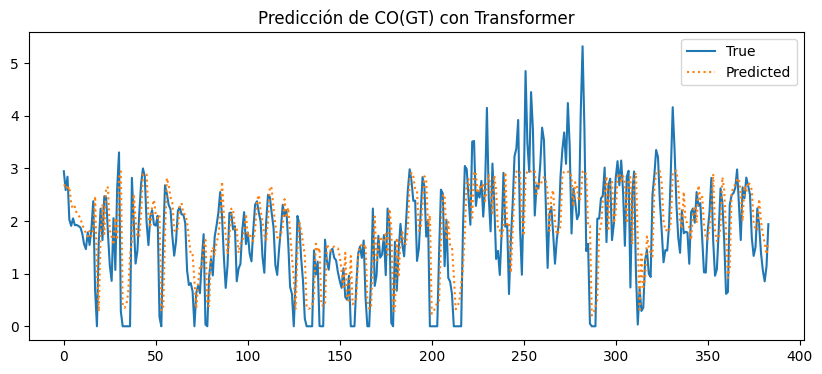

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------------------
# 📌 PREPARAR LOS DATOS
# ----------------------------------------
seq_len = 7  # Usaremos 7 días como ventana (se puede ajustar)

# Tomamos la serie imputada
series = data_imputed['CO(GT)'].to_numpy(dtype=np.float32)

# Generar secuencias y etiquetas
X = []
y = []
for i in range(len(series) - seq_len):
    X.append(series[i:i + seq_len])
    y.append(series[i + seq_len])

X = np.array(X)  # (n_samples, seq_len)
y = np.array(y)  # (n_samples,)

# Añadir dimensión de características (1 característica: CO)
X = X[..., np.newaxis]  # (n_samples, seq_len, 1)

# Crear dataloader
batch_size = 16
dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# ----------------------------------------
# 📌 DEFINIR EL TRANSFORMER
# ----------------------------------------
class SimpleTransformer(nn.Module):
    def __init__(self, seq_len, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = x.permute(1, 0, 2)  # Transformer espera (seq_len, batch, d_model)
        x = self.transformer(x)
        x = x[-1]  # Tomamos la salida del último paso temporal
        x = self.output(x).squeeze(1)  # (batch,)
        return x

# Instanciar el modelo
model = SimpleTransformer(seq_len=seq_len)

# ----------------------------------------
# 📌 ENTRENAR
# ----------------------------------------
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 50
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = loss_fn(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss / len(loader):.4f}")

# ----------------------------------------
# 📌 EVALUAR (p. ej. en todo el conjunto)
# ----------------------------------------
model.eval()
with torch.no_grad():
    y_pred = model(torch.from_numpy(X)).numpy()

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(y, label='True')
plt.plot(y_pred, label='Predicted', linestyle=':')
plt.legend()
plt.title("Predicción de CO(GT) con Transformer")
plt.show()

### ✅ Lo que debes hacer

* Ejecutar el código.
* Observar las predicciones generadas.
* Reflexionar: ¿Cómo se ajusta el modelo a los datos? ¿Qué podríamos mejorar (más capas, regularización, más features)?

## 🎯 Forecasting multivariado de CO con Transformer

El objetivo es modelar y predecir el CO utilizando un Transformer multivariado.  
👉 El modelo aprende a partir de los datos previos y se evalúa su desempeño sobre un conjunto de test (último 20% del tiempo).

Se graficará la serie completa mostrando el ajuste y se compararán los valores reales y predichos en test.


### 📌 Código base

Epoch 1/50, Loss: 1.4065
Epoch 2/50, Loss: 1.0945
Epoch 3/50, Loss: 0.9853
Epoch 4/50, Loss: 0.8455
Epoch 5/50, Loss: 0.7681
Epoch 6/50, Loss: 0.7258
Epoch 7/50, Loss: 0.7080
Epoch 8/50, Loss: 0.6742
Epoch 9/50, Loss: 0.7714
Epoch 10/50, Loss: 0.7036
Epoch 11/50, Loss: 0.6773
Epoch 12/50, Loss: 0.6190
Epoch 13/50, Loss: 0.6782
Epoch 14/50, Loss: 0.6153
Epoch 15/50, Loss: 0.6910
Epoch 16/50, Loss: 0.7826
Epoch 17/50, Loss: 0.7246
Epoch 18/50, Loss: 0.6963
Epoch 19/50, Loss: 0.5899
Epoch 20/50, Loss: 0.6207
Epoch 21/50, Loss: 0.6167
Epoch 22/50, Loss: 0.6280
Epoch 23/50, Loss: 0.6374
Epoch 24/50, Loss: 0.6461
Epoch 25/50, Loss: 0.5655
Epoch 26/50, Loss: 0.5717
Epoch 27/50, Loss: 0.5717
Epoch 28/50, Loss: 0.5764
Epoch 29/50, Loss: 0.6478
Epoch 30/50, Loss: 0.5417
Epoch 31/50, Loss: 0.5930
Epoch 32/50, Loss: 0.5701
Epoch 33/50, Loss: 0.5755
Epoch 34/50, Loss: 0.5314
Epoch 35/50, Loss: 0.5295
Epoch 36/50, Loss: 0.5159
Epoch 37/50, Loss: 0.5461
Epoch 38/50, Loss: 0.5481
Epoch 39/50, Loss: 0.

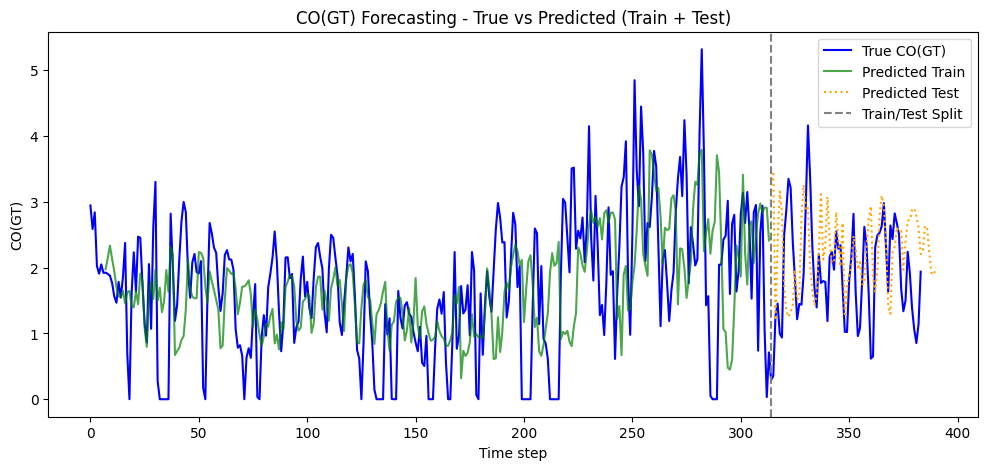

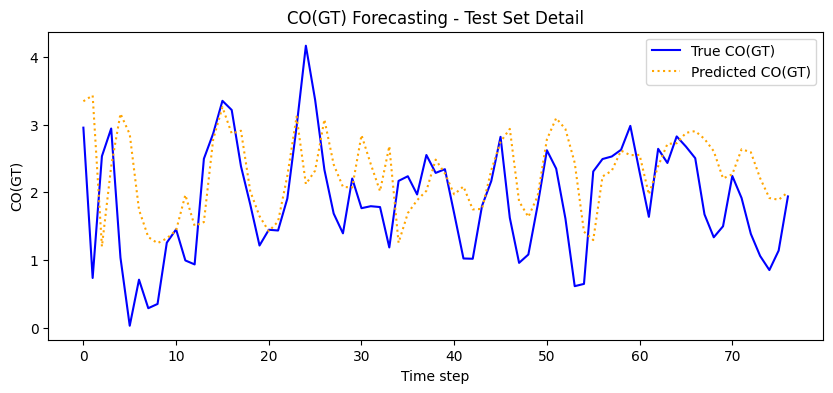

In [37]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# 📌 PREPARAR LOS DATOS
# ----------------------------------------
seq_len = 7
data_arr = data_imputed.to_numpy(dtype=np.float32)

# Secuencias y etiquetas
X = []
y = []
for i in range(len(data_arr) - seq_len):
    X.append(data_arr[i:i + seq_len])
    y.append(data_arr[i + seq_len][data_imputed.columns.get_loc('CO(GT)')])

X = np.array(X)
y = np.array(y)

# Separar train / test (80% / 20%)
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# DataLoader
batch_size = 16
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                          batch_size=batch_size, shuffle=True)

# ----------------------------------------
# 📌 DEFINIR EL TRANSFORMER
# ----------------------------------------
class ForecastTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = x.permute(1, 0, 2)  # (seq_len, batch, d_model)
        x = self.transformer(x)
        x = x[-1]
        x = self.output(x).squeeze(1)
        return x

model = ForecastTransformer(n_features=X.shape[2])

# ----------------------------------------
# 📌 ENTRENAR
# ----------------------------------------
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_X)
        loss = loss_fn(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss / len(train_loader):.4f}")

# ----------------------------------------
# 📌 PREDICCIONES
# ----------------------------------------
model.eval()
with torch.no_grad():
    y_pred_train = model(torch.from_numpy(X_train)).numpy()
    y_pred_test = model(torch.from_numpy(X_test)).numpy()

# ----------------------------------------
# 📌 PLOT DE LA SERIE COMPLETA
# ----------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(range(len(y)), y, label='True CO(GT)', color='blue')
plt.plot(range(seq_len, seq_len + len(y_pred_train)), y_pred_train, label='Predicted Train', color='green', alpha=0.7)
plt.plot(range(seq_len + len(y_pred_train), seq_len + len(y_pred_train) + len(y_pred_test)),
         y_pred_test, label='Predicted Test', color='orange', linestyle=':')
plt.axvline(seq_len + len(y_pred_train), color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title("CO(GT) Forecasting - True vs Predicted (Train + Test)")
plt.xlabel("Time step")
plt.ylabel("CO(GT)")
plt.show()

# ----------------------------------------
# 📌 PLOT COMPARATIVO TEST FINAL
# ----------------------------------------
plt.figure(figsize=(10, 4))
plt.plot(y_test, label='True CO(GT)', color='blue')
plt.plot(y_pred_test, label='Predicted CO(GT)', color='orange', linestyle=':')
plt.legend()
plt.title("CO(GT) Forecasting - Test Set Detail")
plt.xlabel("Time step")
plt.ylabel("CO(GT)")
plt.show()



### ✅ Lo que se espera

* Analizar el gráfico de la serie completa: ¿cómo se ajusta el modelo en train y en test?
* Observar el detalle en test: ¿qué tan bien predice el modelo los valores futuros?
* Proponer mejoras si fuera necesario (más capas, regularización, ajuste de hiperparámetros).

- **Vea las recomendaciones al final de la Opción 2 para incluir posibles mejoras en el modelo.**

# 📝 **Opción 2 - Informe ejecutivo: Imputación de valores faltantes y forecasting de CO(GT)**

## 📌 **Contexto**

El trabajo se realizó sobre un conjunto de datos de calidad del aire recogido en una estación en Italia (2004-2005), con variables como CO(GT), NOx(GT), sensores PT08.\*, temperatura (T), humedad relativa (RH) y humedad absoluta (AH).

## 📝 **Instrucción para el informe ejecutivo**

En esta opción de **informe ejecutivo**, el estudiante no debe centrarse en el código ni en su ejecución. El objetivo es que:

✅ **Analice críticamente los resultados obtenidos**, basándose en:

* Las figuras proporcionadas: visualización de valores faltantes, imputación realizada por SAITS, y predicciones del modelo Transformer.
* Las métricas de evaluación de la imputación (MAE, MSE, RMSE, R² por variable).
* Las métricas del modelo de forecasting (MAE, MSE, RMSE, R² en test).

✅ **Discuta los aciertos y limitaciones**:

* ¿Qué variables se imputaron mejor y por qué?
* ¿Qué patrones se observan en las figuras de imputación y forecasting?
* ¿Qué dificultades tuvo el modelo para generalizar al conjunto de test?

✅ **Proponga recomendaciones para mejorar**:

* Argumentar cómo podrían optimizarse los resultados, considerando pistas como:

  * Aumentar la longitud de la ventana temporal (`seq_len`).
  * Ajustar el número de capas, cabezas de atención y dimensiones del Transformer.
  * Aplicar mayor regularización (dropout, weight decay).
  * Explorar otras arquitecturas como LSTM, TCN o enfoques híbridos.
  * Incorporar variables adicionales o exógenas (por ejemplo: estacionales, día de la semana).

✅ **Redacte un informe claro y estructurado**, que:

* Incluya las figuras proporcionadas como soporte visual.
* Presente las métricas en tablas.
* Explique los resultados en un lenguaje técnico, pero accesible.

### 💡 **Pautas adicionales**

👉 El informe debe responder a preguntas como:

* ¿Qué evidencian los gráficos en relación con la imputación y el forecasting?
* ¿Qué métricas destacan por su buen o mal desempeño?
* ¿Qué tan adecuados son los resultados para un análisis ambiental real?

👉 Se espera un análisis reflexivo y bien argumentado, que sirva como base para futuras mejoras del proceso.


## 🎯 **Generación y visualización de valores faltantes**

Se introdujo un 20% de valores faltantes en bloques para simular fallos de sensores.

📌 **Figura: Matriz de valores faltantes en bloques**
![Matriz de valores faltantes](https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/mv_blocks_ts_4.png)

📌 **Figura: Series temporales con valores faltantes resaltados**
![Series temporales con missing](https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/ts_mv_blocks_ts_4.png)

**Observaciones**:

* Los valores faltantes se distribuyen en tramos consecutivos en todas las variables.
* Las series temporales muestran los huecos (en rojo) que representan los bloques de datos faltantes.

## 🎯 **Imputación con SAITS**

Se aplicó el modelo SAITS para completar los datos.

📌 **Figura: Comparación de series originales vs imputadas**
![Imputación SAITS](https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/ts_imputation_saits_ts_4.png)

### 📊 **Métricas de evaluación de la imputación**

| Variable      | MAE    | MSE       | RMSE    | R²    |
| ------------- | ------ | --------- | ------- | ----- |
| CO(GT)        | 0.281  | 0.106     | 0.326   | 0.746 |
| PT08.S1(CO)   | 61.061 | 5673.883  | 75.325  | 0.850 |
| C6H6(GT)      | 0.995  | 1.878     | 1.370   | 0.872 |
| PT08.S2(NMHC) | 37.641 | 2561.053  | 50.607  | 0.929 |
| NOx(GT)       | 48.429 | 3705.005  | 60.869  | 0.866 |
| PT08.S3(NOx)  | 70.764 | 9218.081  | 96.011  | 0.780 |
| NO2(GT)       | 15.125 | 357.961   | 18.920  | 0.861 |
| PT08.S4(NO2)  | 78.496 | 10095.427 | 100.476 | 0.858 |
| PT08.S5(O3)   | 94.586 | 13372.547 | 115.640 | 0.864 |
| T             | 2.115  | 6.943     | 2.635   | 0.840 |
| RH            | 6.708  | 65.337    | 8.083   | 0.674 |
| AH            | 0.125  | 0.022     | 0.147   | 0.859 |

**Análisis**:

* Las variables como PT08.S2(NMHC), PT08.S1(CO) y C6H6(GT) presentan R² altos (>0.85), indicando una buena imputación.
* RH muestra menor desempeño (R² = 0.674), probablemente debido a mayor variabilidad o menor dependencia de otras variables.

## 🎯 **Forecasting multivariado de CO(GT) con Transformer**

El modelo Transformer fue entrenado con las variables imputadas para predecir CO(GT).

📌 **Figura: True vs Predicted (Train + Test)**
![Transformer CO Forecasting](https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/transformer_co_ts_4.png)

### 📊 **Métricas de forecasting (test set)**

| Métrica | Valor  |
| ------- | ------ |
| MAE     | 0.709  |
| MSE     | 0.884  |
| RMSE    | 0.940  |
| R²      | -0.404 |

**Análisis**:

* El R² negativo indica que el modelo no supera un predictor constante (media de la serie), sugiriendo sobreajuste o insuficiente captura de la dinámica temporal.
* Visualmente, el modelo sigue bien la tendencia en train, pero las predicciones en test son planas o desacopladas del patrón real.

## 💡 **Reflexiones y propuestas de mejora**

✅ **SAITS**

* SAITS logra buena calidad de imputación en la mayoría de variables.
* Las variables con menor R² podrían beneficiarse de una imputación combinada (e.g. interpolación + SAITS).

✅ **Transformer**

* Incrementar la longitud de las secuencias (por ejemplo seq\_len > 7).
* Añadir regularización (mayor dropout, weight decay).
* Probar ajustes de hiperparámetros: más capas, más cabezas de atención.
* Explorar arquitecturas alternativas como LSTM o TCN.

✅ **General**

* Considerar agregar variables externas (e.g. día de la semana) como input al modelo.

👉 **Siguiente paso sugerido:** Implementar un proceso de validación cruzada y tuning de hiperparámetros para el Transformer.